# AutoEIT — Transcription Analysis
Builds per-recording `summary.json` files, then aggregates them for overall analysis.

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_ROOT = Path("../../data/transcribed/v1")
VERSIONS = ["version_a", "version_b"]

## Build per-recording summaries
Reads all `item_*.json` files for each recording, computes summary metrics, saves `summary.json`.

In [3]:
def summarize_item(item_path: Path) -> dict:
    with open(item_path) as f:
        data = json.load(f)

    index = int(re.search(r"item_(\d+)", item_path.stem).group(1))
    text = " ".join(seg["text"].strip() for seg in data["segments"]).strip()

    all_words = [w for seg in data["segments"] for w in seg.get("words", [])]
    word_count = len(all_words)
    mean_word_prob = round(sum(w["prob"] for w in all_words) / word_count, 4) if all_words else None

    return {
        "index": index,
        "duration": data["duration"],
        "language": data["language"],
        "language_probability": data["language_probability"],
        "word_count": word_count,
        "mean_word_prob": mean_word_prob,
        "text": text,
        "empty": word_count == 0 or len(text) < 3,
    }

In [4]:
def build_recording_summary(recording_dir: Path, version: str) -> dict:
    item_files = sorted(recording_dir.glob("item_*.json"),
                        key=lambda p: int(re.search(r"item_(\d+)", p.stem).group(1)))
    items = [summarize_item(p) for p in item_files]
    return {
        "recording": recording_dir.name,
        "version": version,
        "item_count": len(items),
        "items": items,
    }

In [5]:
built = 0
skipped = 0

for version in VERSIONS:
    version_dir = TRANSCRIBED_ROOT / version
    if not version_dir.exists():
        print(f"Not found: {version_dir}")
        continue
    for recording_dir in sorted(version_dir.iterdir()):
        if not recording_dir.is_dir():
            continue
        summary_path = recording_dir / "summary.json"
        if summary_path.exists():
            skipped += 1
            continue
        summary = build_recording_summary(recording_dir, version)
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary, f, ensure_ascii=False, indent=2)
        built += 1

print(f"Built {built} summaries, skipped {skipped} (already exist)")

Built 0 summaries, skipped 205 (already exist)


## Load summaries into DataFrames

In [6]:
recording_rows = []
item_rows = []

for version in VERSIONS:
    version_dir = TRANSCRIBED_ROOT / version
    if not version_dir.exists():
        continue
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path) as f:
            s = json.load(f)
        recording_rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
            "empty_count": sum(1 for it in s["items"] if it["empty"]),
            "mean_word_prob": round(
                sum(it["mean_word_prob"] for it in s["items"] if it["mean_word_prob"] is not None) /
                max(1, sum(1 for it in s["items"] if it["mean_word_prob"] is not None)), 4
            ),
            "mean_duration": round(sum(it["duration"] for it in s["items"]) / max(1, s["item_count"]), 3),
        })
        for it in s["items"]:
            item_rows.append({
                "recording": s["recording"],
                "version": s["version"],
                **it,
            })

df_rec = pd.DataFrame(recording_rows)
df_items = pd.DataFrame(item_rows)
print(f"{len(df_rec)} recordings, {len(df_items)} items total")
df_rec.head()

205 recordings, 8481 items total


,recording,version,item_count,empty_count,mean_word_prob,mean_duration
0,038.068_EITv-1A,version_a,43,0,0.7965,5.760
1,038.069_EITv-2A,version_a,38,0,0.9318,4.921
2,038.070_EITv-1A,version_a,37,0,0.9202,4.873
3,038.071_EITv2A,version_a,37,0,0.9407,5.673
4,038.072_EITv1A,version_a,38,0,0.9229,5.576


## 1. Overall recording stats

In [7]:
cols = ["item_count", "empty_count", "mean_word_prob", "mean_duration"]
print("=== Overall ===")
display(df_rec[cols].describe().round(3))
print("\n=== By version ===")
display(df_rec.groupby("version")[cols].describe().round(3))

=== Overall ===


,item_count,empty_count,mean_word_prob,mean_duration
count,205.000,205.000,205.000,205.000
mean,41.371,0.083,0.851,6.028
std,12.208,0.310,0.083,2.366
min,1.000,0.000,0.595,3.654
25%,37.000,0.000,0.804,5.054
50%,38.000,0.000,0.860,5.515
75%,40.000,0.000,0.920,6.171
max,75.000,2.000,0.977,26.957



=== By version ===


item_count                                              empty_count  \
               count    mean     std  min   25%   50%   75%   max       count   
version                                                                         
version_a      102.0  40.441  10.794  1.0  37.0  38.0  40.0  72.0       102.0   
version_b      103.0  42.291  13.453  1.0  37.0  38.0  40.0  75.0       103.0   

                  ... mean_word_prob        mean_duration                \
            mean  ...            75%    max         count   mean    std   
version           ...                                                     
version_a  0.098  ...          0.923  0.973         102.0  6.249  2.402   
version_b  0.068  ...          0.910  0.977         103.0  5.809  2.321   

                                               
             min    25%    50%    75%     max  
version                                        
version_a  4.062  5.140  5.593  6.448  24.600  
version_b  3.654  4.944  5.472  6.092  26.957  

[2 rows x 32 columns]

## 2. Language detection by item index
Shows which language Whisper detected at each item position across all recordings.

Overall language distribution:


,item_count
language_grouped,
es,5036
en,2539
other,906


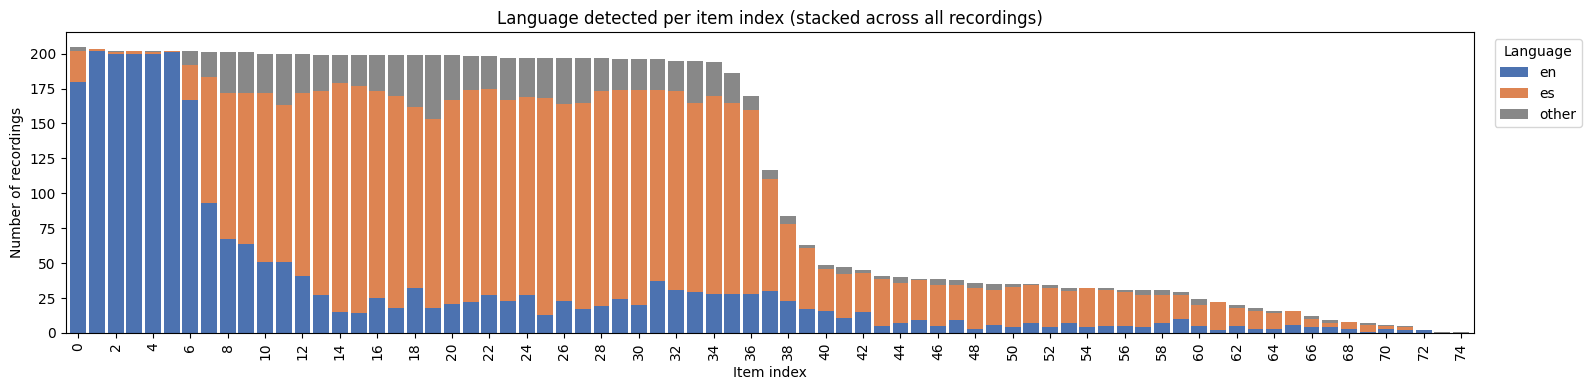

In [8]:
lang_colors = {"en": "#4C72B0", "es": "#DD8452", "other": "#888888"}

df_items["language_grouped"] = df_items["language"].apply(
    lambda l: l if l in ("en", "es") else "other"
)

print("Overall language distribution:")
display(df_items["language_grouped"].value_counts().to_frame(name="item_count"))

lang_pivot = (
    df_items.groupby(["index", "language_grouped"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["en", "es", "other"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 4))
lang_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85,
                color=[lang_colors[c] for c in lang_pivot.columns])
ax.set_title("Language detected per item index (stacked across all recordings)", fontsize=12)
ax.set_xlabel("Item index")
ax.set_ylabel("Number of recordings")
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.legend(title="Language", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.savefig("../plots/language_by_index.png", dpi=150)
plt.show()

In [9]:
suspicious = df_items[
    (df_items["language_grouped"] == "other") |
    ((df_items["language_grouped"] == "en") & (df_items["index"] > 7))
][["recording", "version", "index", "language", "language_probability", "text"]].sort_values(
    ["recording", "index"]
).reset_index(drop=True)

print(f"{len(suspicious)} suspicious item(s) across {suspicious['recording'].nunique()} recording(s):\n")
# pd.set_option("display.max_rows", None)
display(suspicious)
# pd.reset_option("display.max_rows")

2002 suspicious item(s) across 187 recording(s):



,recording,version,index,language,language_probability,text
0,038.068_EITv-1A,version_a,10,en,0.3342,The Pharaoh that dyanai pedo.
1,038.068_EITv-1A,version_a,11,pt,0.8398,Eu se dute cada manhã.
2,038.068_EITv-1A,version_a,12,en,0.3796,Did you say that you're going to be leaving?
3,038.068_EITv-1A,version_a,13,fr,0.6782,Tout ce qui peut se faire très bien.
4,038.068_EITv-1A,version_a,20,la,0.5205,Chiaro un casa in cae vivam animalis.
...,...,...,...,...,...,...
1997,038067_EITv2-2A,version_a,20,la,0.6748,A nosotros les gustan las fiestas muy grandiosas.
1998,038067_EITv2-2A,version_a,21,pt,0.6763,Ela só bebe cerveja e não come nada.
1999,038067_EITv2-2A,version_a,27,la,0.3955,Una amiga mia cuida los ninos del vecino.
2000,038067_EITv2-2A,version_a,31,en,0.6660,This place they sell their El Trabajo.


## 3. Word-level confidence distribution

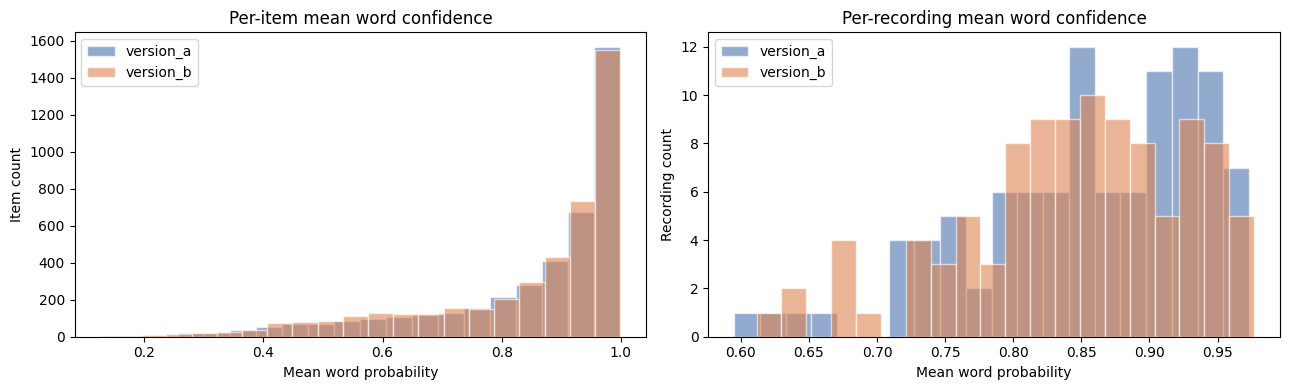

In [10]:
colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-item mean confidence histogram
ax = axes[0]
for ver in VERSIONS:
    sub = df_items[df_items["version"] == ver]["mean_word_prob"].dropna()
    ax.hist(sub, bins=20, alpha=0.6, label=ver, color=colors[ver], edgecolor="white")
ax.set_title("Per-item mean word confidence", fontsize=12)
ax.set_xlabel("Mean word probability")
ax.set_ylabel("Item count")
ax.legend()

# Per-recording mean confidence
ax = axes[1]
for ver in VERSIONS:
    sub = df_rec[df_rec["version"] == ver]["mean_word_prob"]
    ax.hist(sub, bins=20, alpha=0.6, label=ver, color=colors[ver], edgecolor="white")
ax.set_title("Per-recording mean word confidence", fontsize=12)
ax.set_xlabel("Mean word probability")
ax.set_ylabel("Recording count")
ax.legend()

fig.tight_layout()
plt.savefig("../plots/confidence_distribution.png", dpi=150)
plt.show()

## 4. Empty transcripts

In [11]:
empty_items = df_items[df_items["empty"]]
print(f"{len(empty_items)} empty items across {empty_items['recording'].nunique()} recordings\n")

print("Empty items by index:")
display(empty_items["index"].value_counts().sort_index().to_frame())

print("\nRecordings with most empty items:")
display(
    df_rec[df_rec["empty_count"] > 0][["recording", "version", "item_count", "empty_count"]]
    .sort_values("empty_count", ascending=False)
    .reset_index(drop=True)
)

17 empty items across 15 recordings

Empty items by index:


,count
index,
6,1
11,1
14,1
18,2
19,2
23,1
24,1
26,1
27,1



Recordings with most empty items:


,recording,version,item_count,empty_count
0,038.105_EIT2_vA,version_a,37,2
1,038036_EIT-1B,version_b,35,2
2,038.102_EIT1_vA,version_a,49,1
3,038014_EIT-2A,version_a,37,1
4,038018_EIT-2A,version_a,39,1
5,038025_EIT-1A,version_a,38,1
6,038012_EIT-2A,version_a,72,1
7,038029_EIT-1A,version_a,43,1
8,038029_EITv_1A,version_a,43,1
9,038.072_EITv2B,version_b,38,1


## 5. Anomalies — recordings with unexpected item counts

In [12]:
mean_items = df_rec["item_count"].mean()
std_items = df_rec["item_count"].std()
threshold = mean_items - 2 * std_items

anomalies = df_rec[df_rec["item_count"] < threshold]
print(f"Mean item count: {mean_items:.1f}  |  Threshold (mean − 2σ): {threshold:.1f}")
print(f"{len(anomalies)} anomalous recording(s):")
display(anomalies[["recording", "version", "item_count", "empty_count"]].reset_index(drop=True))

Mean item count: 41.4  |  Threshold (mean − 2σ): 17.0
6 anomalous recording(s):


,recording,version,item_count,empty_count
0,038063_EITv-2A,version_a,13,0
1,038066_EITv-1A,version_a,1,0
2,038test_EITvA1,version_a,2,0
3,038039_EITv-2B,version_b,1,0
4,038065_EITv-1B,version_b,10,0
5,038test_EITvB2,version_b,7,0


## 6. Sample transcripts — first few items of one recording

In [13]:
SAMPLE_RECORDING = df_rec.iloc[0]["recording"]
SAMPLE_VERSION = df_rec.iloc[0]["version"]

sample = df_items[(df_items["recording"] == SAMPLE_RECORDING) & (df_items["version"] == SAMPLE_VERSION)]
print(f"First 10 items of {SAMPLE_RECORDING} ({SAMPLE_VERSION}):\n")
for _, row in sample.head(10).iterrows():
    print(f"  [{row['index']:2d}] lang={row['language']} ({row['language_probability']:.2f})  "
          f"words={row['word_count']}  conf={row['mean_word_prob']}")
    print(f"       {row['text'][:120]}")

First 10 items of 038.068_EITv-1A (version_a):

  [ 0] lang=en (1.00)  words=98  conf=0.8954
       I think this one's still going. Oh, shoot. Sorry. That's all good. Go back to the beginning. Okay. Okay. Is it stopped y
  [ 1] lang=en (0.96)  words=2  conf=0.3637
       Oh yeah.
  [ 2] lang=en (0.99)  words=5  conf=0.9674
       We drove to the park.
  [ 3] lang=en (1.00)  words=5  conf=0.9971
       I'll call her tomorrow night.
  [ 4] lang=en (0.99)  words=8  conf=0.9635
       You can buy meat at the butcher shop.
  [ 5] lang=en (0.97)  words=8  conf=0.9704
       My brother just bought a brand new computer.
  [ 6] lang=en (0.99)  words=11  conf=0.9818
       Sometimes they take their dog for a walk in the park.
  [ 7] lang=en (0.98)  words=13  conf=0.9884
       We're going to play volleyball at the gym that I told you about.
  [ 8] lang=es (0.87)  words=4  conf=0.9856
       Quiero cortarme el pelo.
  [ 9] lang=es (0.61)  words=6  conf=0.9871
       El libro está en la mesa.
